# Word2Vec

## Tanító táblázat elkészítése

In [22]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/word2vec_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,349,644 → Szűrt sorok: 22,576,759


19

## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,433,553 sor
✅ Validációs halmaz: 1,143,206 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.16111	validation_0-map@10:0.12673
[50]	validation_0-ndcg@10:0.18074	validation_0-map@10:0.14571
[100]	validation_0-ndcg@10:0.18147	validation_0-map@10:0.14801
[131]	validation_0-ndcg@10:0.18345	validation_0-map@10:0.14962

💾 Modell sikeresen elmentve!

📊 Jellemzők fontosságának (Feature Importance) kirajzolása...


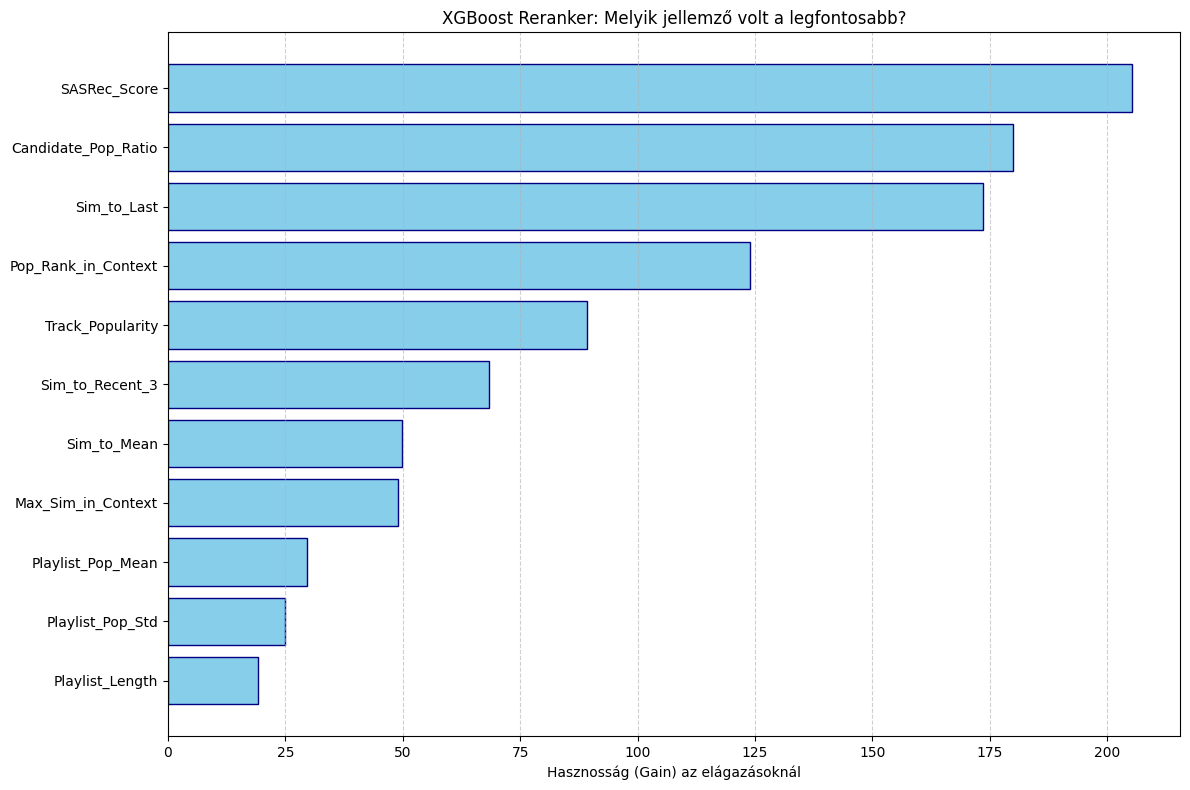

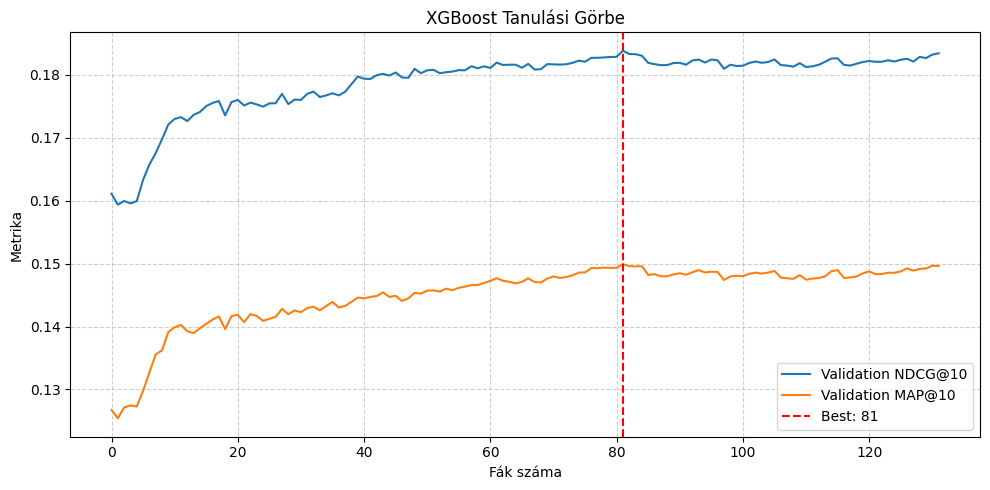

🏆 Legjobb iteráció: 81
🏆 Legjobb NDCG@10: 0.1839


In [23]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
# A Playlist_ID és Candidate_ID azonosítók, ezeket nem tanítjuk!
# BELEKERÜLTEK AZ ÚJ RELATÍV ÉS NORMALIZÁLT JELLEMZŐK:

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',
    'Max_Sim_in_Context',
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
# Különválasztunk egy kis részt (pl. 5000 listát) ellenőrzésnek a tanítás alatt
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',       # ÚJ: Próbáld ki a Pairwise rangsorolást! (vagy hagyd rank:ndcg-n)
    n_estimators=2000,               # ÚJ: Felemelve 2000-re, az Early Stopping majd megállítja!
    learning_rate=0.05,              
    max_depth=6,                     
    subsample=0.8,                   
    colsample_bytree=0.8,            
    min_child_weight=10,              
    tree_method='hist',              
    random_state=42,
    # ÚJ: Több metrika figyelése! Az első metrika alapján fog működni az early_stopping.
    eval_metric=['ndcg@10', 'map@10'], 
    early_stopping_rounds=50         
)

# Tanítás monitoringgal
eval_result = ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)], # ÚJ: A Train-t is betesszük, hogy lássuk az Overfittinget!
    eval_qid=[qid_val],
    verbose=50 # ÚJ: Elég 50 fánként kiírni, ha 2000 a max
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

results = ranker.evals_result()
epochs = len(results['validation_0']['ndcg@10'])

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--', label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

## Teszt tábla generálás

In [24]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/word2vec_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,351,673 → Szűrt sorok: 22,626,335


19

## Kiértékelés

In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',
    'Max_Sim_in_Context',
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0224  0.0631  0.0943  0.1331  0.2016  0.2689  0.3452  0.4591
HR_XGB     0.0397  0.0964  0.1345  0.1842  0.2663  0.3370  0.4041  0.4591
HR_imp%   77.5225 52.6518 42.6952 38.4359 32.1028 25.3394 17.0653  0.0000
NDCG_SAS   0.0224  0.0430  0.0530  0.0628  0.0763  0.0872  0.0979  0.1116
NDCG_XGB   0.0397  0.0686  0.0808  0.0933  0.1096  0.1211  0.1305  0.1372
NDCG_imp% 77.5225 59.4959 52.5340 48.6972 43.6005 38.8213 33.3121 22.9379
MAP_SAS    0.0224  0.0364  0.0405  0.0432  0.0453  0.0463  0.0468  0.0472
MAP_XGB    0.0397  0.0594  0.0645  0.0679  0.0705  0.0715  0.0720  0.0722
MAP_imp%  77.5225 63.3370 59.2414 57.2815 55.5268 54.5102 53.7553 52.9553

🖱️ Clicks SASRec:  33.0283
🖱️ Clicks XGBoost: 30.8968
🚀 Clicks javulás: -6.45%


# Hibrid tér (sok feature)

## Tanító tábla

In [48]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,345,936 → Szűrt sorok: 22,606,455


19

## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,463,303 sor
✅ Validációs halmaz: 1,143,152 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14656	validation_0-map@10:0.11029
[50]	validation_0-ndcg@10:0.14580	validation_0-map@10:0.11431
[100]	validation_0-ndcg@10:0.14840	validation_0-map@10:0.11527
[150]	validation_0-ndcg@10:0.14773	validation_0-map@10:0.11528
[200]	validation_0-ndcg@10:0.14915	validation_0-map@10:0.11636
[250]	validation_0-ndcg@10:0.14835	validation_0-map@10:0.11485
[300]	validation_0-ndcg@10:0.14944	validation_0-map@10:0.11606
[350]	validation_0-ndcg@10:0.14964	validation_0-map@10:0.11614
[400]	validation_0-ndcg@10:0.14916	validation_0-map@10:0.11571
[450]	validation_0-ndcg@10:0.15037	validation_0-map@10:0.11684
[500]	validation_0-ndcg@10:0.15051	validation_0-map@10:0.11693
[550]	validation_0-ndcg@10:0.15111	validation_0-map@10:0.11795
[600]	validation_0-ndcg@10:0.15112	validation_0-map@10:0.11745
[650]	validation_0-ndcg@10:0.15129	validation_0-map@10:0.1

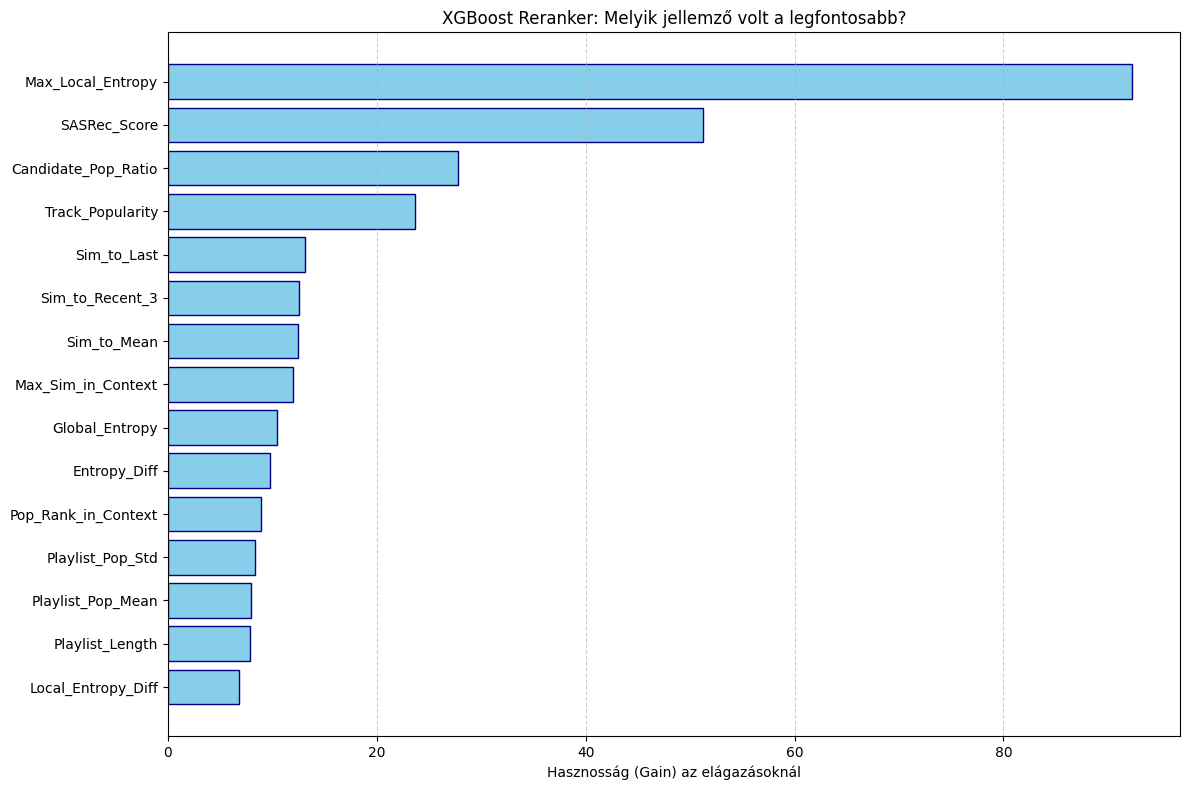


📈 Tanulási görbe...


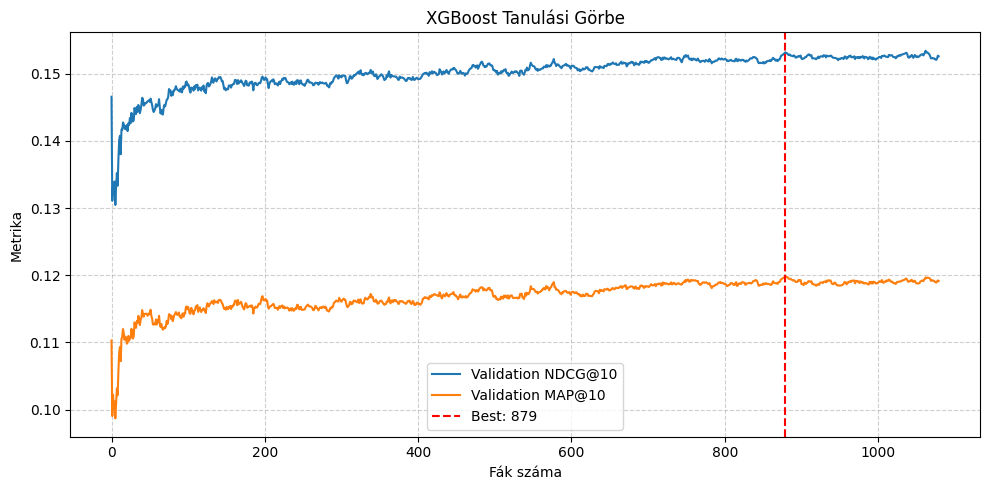

🏆 Legjobb iteráció: 879
🏆 Legjobb NDCG@10: 0.1534


In [14]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

## Teszt tábla

In [50]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,354,168 → Szűrt sorok: 22,564,094


19

## Kiértékelés

In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.4578
HR_XGB     0.0314  0.0811  0.1168  0.1639  0.2448  0.3196  0.4578
HR_imp%   42.1461 30.0129 24.6156 24.2737 22.0920 19.4512  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.1110
NDCG_XGB   0.0314  0.0565  0.0680  0.0799  0.0959  0.1080  0.1263
NDCG_imp% 42.1461 32.9306 29.3678 28.4456 26.5596 24.6993 13.7765
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0467
MAP_XGB    0.0314  0.0484  0.0532  0.0564  0.0590  0.0600  0.0608
MAP_imp%  42.1461 34.6200 32.6040 32.0376 31.3603 30.9641 30.0596

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.2668
🚀 Clicks javulás: -5.49%


# Hibrid tér kevesebb feature

## Feature-ök elemzése

- Sim_to_Recent_3 nem kell
- Max_Sim_Context nem kell
- Playlist_Pop_Mean nem kell
- Local_Entropy_Diff nem kell

### Kolleráció

📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...
📊 Korrelációs mátrix számítása...


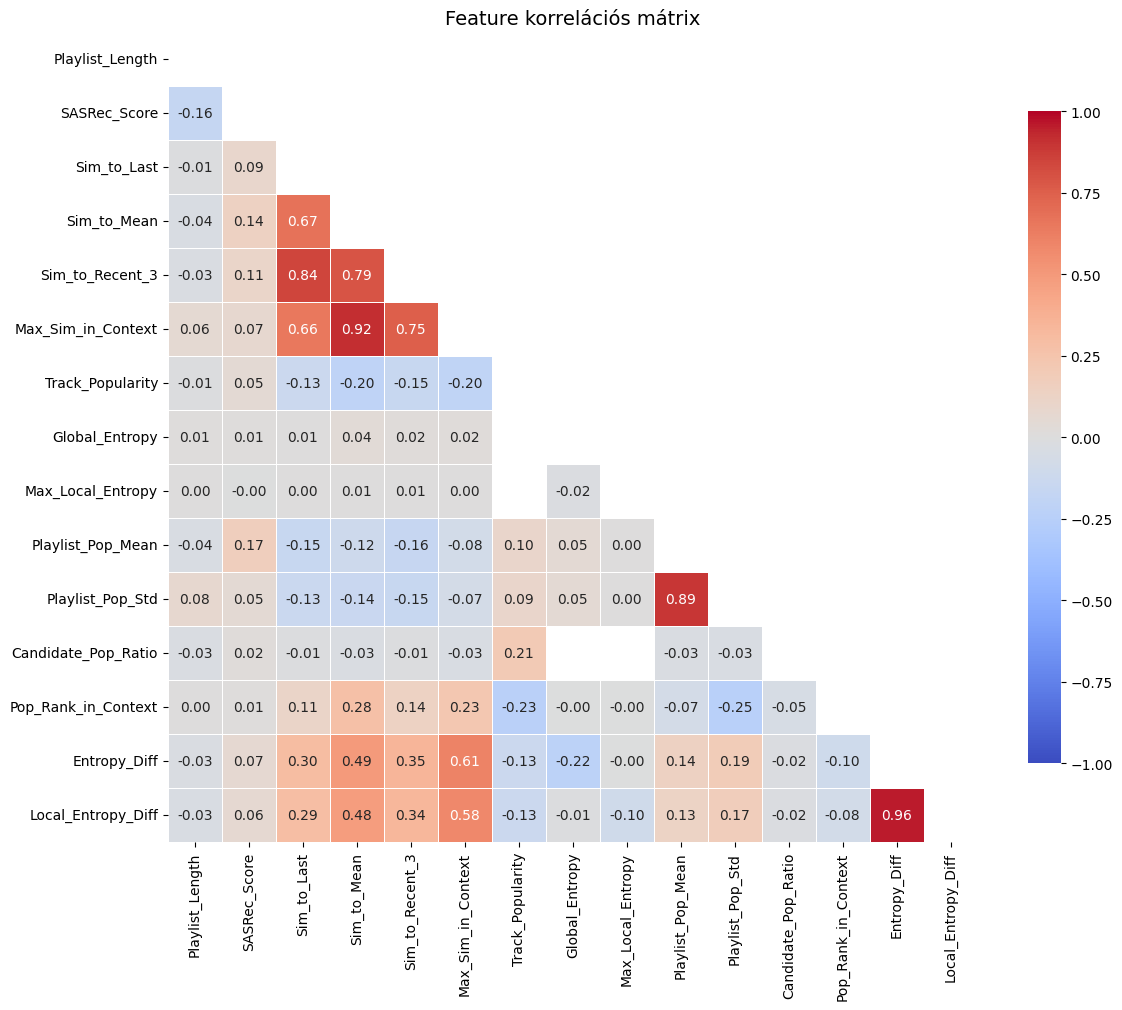


⚠️ Erős korreláció (|r| > 0.7):
  Sim_to_Recent_3 <-> Sim_to_Last: 0.845
  Sim_to_Recent_3 <-> Sim_to_Mean: 0.794
  Max_Sim_in_Context <-> Sim_to_Mean: 0.920
  Max_Sim_in_Context <-> Sim_to_Recent_3: 0.752
  Playlist_Pop_Std <-> Playlist_Pop_Mean: 0.891
  Local_Entropy_Diff <-> Entropy_Diff: 0.960


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff',
]

print("📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...")
df = pd.read_parquet(
    "../Models/xgboost_train_dataset_hybrid_filtered.parquet",
    columns=features
).head(500_000)

print("📊 Korrelációs mátrix számítása...")
corr = df[features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Csak az alsó háromszög
sns.heatmap(
    corr,
    mask=mask,
    annot=True,       # Számok kiírása
    fmt=".2f",        # 2 tizedesjegy
    cmap="coolwarm",  # Piros = pozitív, kék = negatív korreláció
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature korrelációs mátrix", fontsize=14)
plt.tight_layout()
plt.show()

# Szöveges összefoglaló: mely párok korrelálnak erősen (|r| > 0.7)?
print("\n⚠️ Erős korreláció (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {val:.3f}")

## Tanító tábla

In [7]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_v2.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]
        
    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None  # Folyamatos Parquet writer

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []
    
    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))
        
    if not batch_padded: continue
    
    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)
    
    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]
        
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)
        
        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        
        context_entropies = [track_global_entropy[t] for t in context if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if len(context_entropies) > 0 else 0.0
        
        pos_samples = []
        neg_samples = []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break
            
            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]
            
            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            
            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "SASRec_Rank": current_rank,
                "Relative_Rank": float(current_rank / TOP_K),
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Entropy_Diff": float(entropy_diff),
                "Is_CNN_Only": track_is_cnn[cand_id],
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH: minden 500.000 sor után lemezre írás ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

print(f"🎉 KÉSZ! Az összes adat (kb. {global_playlist_id * TOP_K:,} sor) sikeresen lemezre írva.")

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🎉 KÉSZ! Az összes adat (kb. 49,589,500 sor) sikeresen lemezre írva.


## Kidobom azokat a listákat, amely nem tartalmaz pozitívat

In [11]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import gc

INPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_v2.parquet"
OUTPUT_PARQUET = "../Models/xgboost_train_dataset_hybrid_v2_filtered.parquet"

print("📂 Pozitív Playlist_ID-k beolvasása...")
# Csak a Label oszlopot olvassuk be először — gyors és memóriakímélő
df_labels = pd.read_parquet(INPUT_PARQUET, columns=['Playlist_ID', 'Label'])
lists_with_pos = set(df_labels[df_labels['Label'] == 1]['Playlist_ID'].unique())
del df_labels
gc.collect()
print(f"✅ Megtartandó listák száma: {len(lists_with_pos):,}")

print("📖 Szűrés és streaming írás...")
parquet_file = pq.ParquetFile(INPUT_PARQUET)
writer = None

for batch in parquet_file.iter_batches(batch_size=500_000):
    df_chunk = batch.to_pandas()
    df_filtered = df_chunk[df_chunk['Playlist_ID'].isin(lists_with_pos)]
    
    if len(df_filtered) == 0:
        continue
    
    table = pa.Table.from_pandas(df_filtered, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)
    
    del df_chunk, df_filtered, table
    gc.collect()

if writer is not None:
    writer.close()

print("🎉 KÉSZ! Szűrt fájl elmentve.")

📂 Pozitív Playlist_ID-k beolvasása...
✅ Megtartandó listák száma: 45,392
📖 Szűrés és streaming írás...
🎉 KÉSZ! Szűrt fájl elmentve.


In [1]:
import pandas as pd

# Csak a metaadatokat és az első 5 sort olvassuk be
df_peek = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_v2_filtered.parquet", engine='pyarrow').head()

print("📋 OSZLOPOK LISTÁJA:")
print(df_peek.columns.tolist())

print("\n📊 ADAT-ÍZELÍTŐ (Első 5 sor):")
display(df_peek)

print("\n🔬 ADATTÍPUSOK:")
print(df_peek.dtypes)

📋 OSZLOPOK LISTÁJA:
['Playlist_ID', 'Candidate_ID', 'SASRec_Rank', 'Relative_Rank', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean', 'Track_Popularity', 'Global_Entropy', 'Max_Local_Entropy', 'Candidate_Pop_Ratio', 'Entropy_Diff', 'Is_CNN_Only', 'Label']

📊 ADAT-ÍZELÍTŐ (Első 5 sor):


,Playlist_ID,Candidate_ID,SASRec_Rank,Relative_Rank,SASRec_Score,Sim_to_Last,Sim_to_Mean,Track_Popularity,Global_Entropy,Max_Local_Entropy,Candidate_Pop_Ratio,Entropy_Diff,Is_CNN_Only,Label
0,0,4669,79,0.158,0.203485,0.921682,0.941772,0,1.950334,4.584962,0.0,0.020329,1,1
1,0,178,1,0.002,0.289247,0.916837,0.968866,0,1.414498,4.584962,0.0,0.515506,1,0
2,0,971,2,0.004,0.268816,0.724710,0.766873,6368,NaN,NaN,6368.0,-1.000000,0,0
3,0,370,3,0.006,0.262659,0.922117,0.979192,0,1.684140,4.584962,0.0,0.245865,1,0
4,0,355,4,0.008,0.262077,0.719813,0.707542,10519,NaN,NaN,10519.0,-1.000000,0,0



🔬 ADATTÍPUSOK:
Playlist_ID              int64
Candidate_ID             int64
SASRec_Rank              int64
Relative_Rank          float64
SASRec_Score           float64
Sim_to_Last            float64
Sim_to_Mean            float64
Track_Popularity         int64
Global_Entropy         float32
Max_Local_Entropy      float32
Candidate_Pop_Ratio    float64
Entropy_Diff           float64
Is_CNN_Only              int64
Label                    int64
dtype: object


## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,463,303 sor
✅ Validációs halmaz: 1,143,152 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14291	validation_0-map@10:0.10859
[50]	validation_0-ndcg@10:0.14121	validation_0-map@10:0.11009
[100]	validation_0-ndcg@10:0.14322	validation_0-map@10:0.11130
[150]	validation_0-ndcg@10:0.14241	validation_0-map@10:0.10976
[200]	validation_0-ndcg@10:0.14277	validation_0-map@10:0.11025
[250]	validation_0-ndcg@10:0.14386	validation_0-map@10:0.11079
[256]	validation_0-ndcg@10:0.14457	validation_0-map@10:0.11099

💾 Modell sikeresen elmentve!

📊 Jellemzők fontosságának (Feature Importance) kirajzolása...


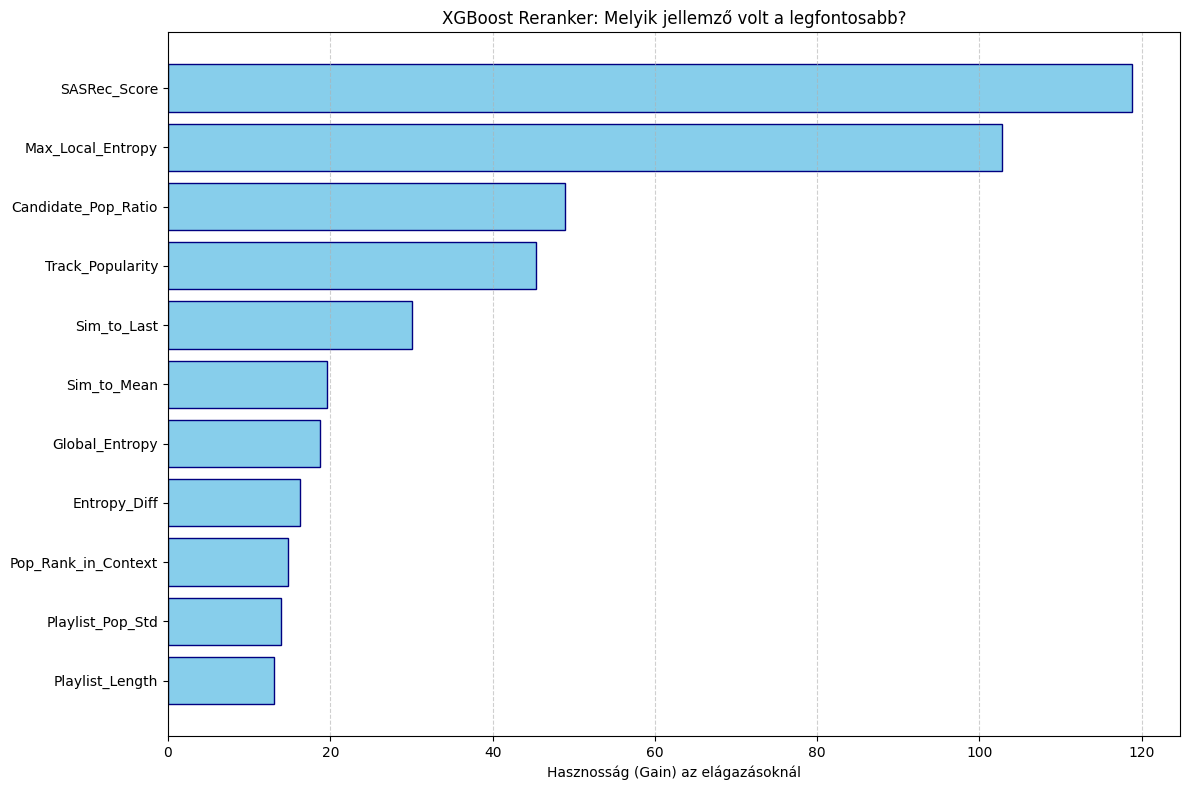

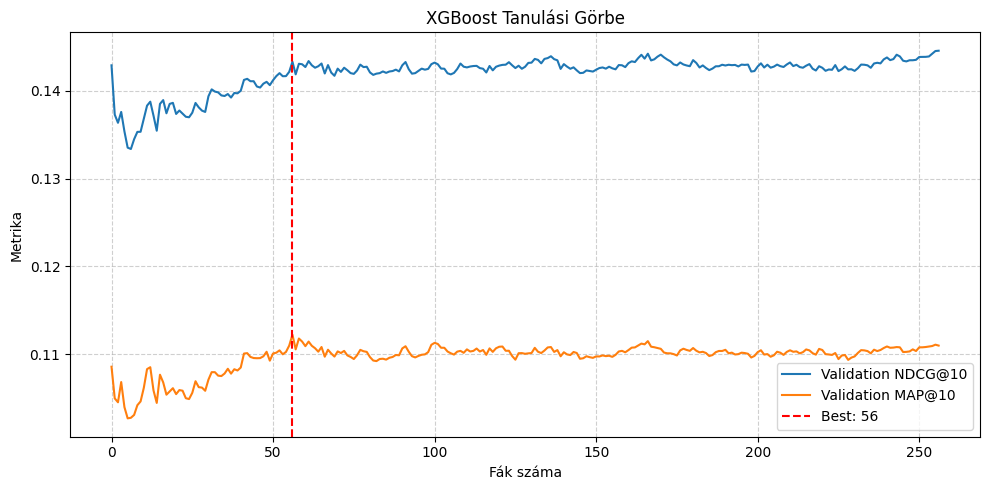

🏆 Legjobb iteráció: 56
🏆 Legjobb NDCG@10: 0.1446


In [19]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_filtered.parquet")
df = df.sort_values("Playlist_ID").reset_index(drop=True)

shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
# A Playlist_ID és Candidate_ID azonosítók, ezeket nem tanítjuk!
# BELEKERÜLTEK AZ ÚJ RELATÍV ÉS NORMALIZÁLT JELLEMZŐK:
features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
    'Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
# Különválasztunk egy kis részt (pl. 5000 listát) ellenőrzésnek a tanítás alatt
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',       # ÚJ: Próbáld ki a Pairwise rangsorolást! (vagy hagyd rank:ndcg-n)
    n_estimators=2000,               # ÚJ: Felemelve 2000-re, az Early Stopping majd megállítja!
    learning_rate=0.05,              
    max_depth=6,                     
    subsample=0.8,                   
    colsample_bytree=0.8,            
    min_child_weight=10,              
    tree_method='hist',              
    random_state=42,
    # ÚJ: Több metrika figyelése! Az első metrika alapján fog működni az early_stopping.
    eval_metric=['ndcg@10', 'map@10'], 
    early_stopping_rounds=200        
)

# Tanítás monitoringgal
eval_result = ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)], # ÚJ: A Train-t is betesszük, hogy lássuk az Overfittinget!
    eval_qid=[qid_val],
    verbose=50 # ÚJ: Elég 50 fánként kiírni, ha 2000 a max
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_v2.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

results = ranker.evals_result()
epochs = len(results['validation_0']['ndcg@10'])

plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--', label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

In [35]:
from sklearn.metrics import ndcg_score
import numpy as np

ndcg_values = []
for pid, group in df_val.groupby('Playlist_ID'):
    if group['Label'].sum() == 0:
        continue
    y_true = group['Label'].values
    y_score = -group['SASRec_Rank'].values  # Negatív mert kisebb rank = jobb
    ndcg_values.append(ndcg_score([y_true], [y_score], k=10))

print(f"SASRec NDCG@10 a val halmazon: {np.mean(ndcg_values):.4f}")

SASRec NDCG@10 a val halmazon: 0.1134


## Kiértékelés

📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...
📊 Korrelációs mátrix számítása...


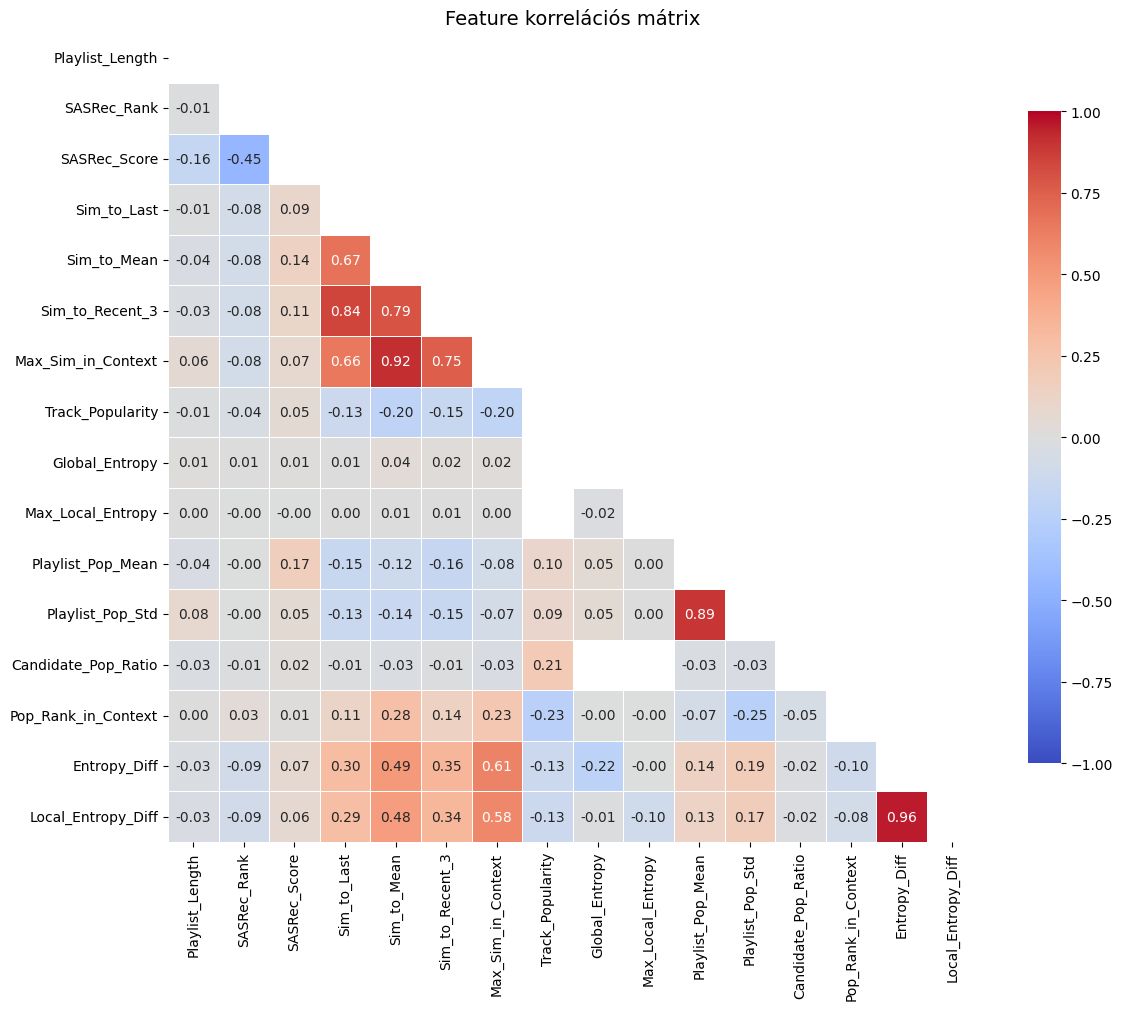


⚠️ Erős korreláció (|r| > 0.7):
  Sim_to_Recent_3 <-> Sim_to_Last: 0.845
  Sim_to_Recent_3 <-> Sim_to_Mean: 0.794
  Max_Sim_in_Context <-> Sim_to_Mean: 0.920
  Max_Sim_in_Context <-> Sim_to_Recent_3: 0.752
  Playlist_Pop_Std <-> Playlist_Pop_Mean: 0.891
  Local_Entropy_Diff <-> Entropy_Diff: 0.960


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'Playlist_Length',
    'SASRec_Rank',
    #'Relative_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff',
    #'Is_CNN_Only'
]

print("📂 Minta betöltése (első 500k sor elég a korreláció becsléshez)...")
df = pd.read_parquet(
    "../Models/xgboost_train_dataset_hybrid_filtered.parquet",
    columns=features
).head(500_000)

print("📊 Korrelációs mátrix számítása...")
corr = df[features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Csak az alsó háromszög
sns.heatmap(
    corr,
    mask=mask,
    annot=True,       # Számok kiírása
    fmt=".2f",        # 2 tizedesjegy
    cmap="coolwarm",  # Piros = pozitív, kék = negatív korreláció
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature korrelációs mátrix", fontsize=14)
plt.tight_layout()
plt.show()

# Szöveges összefoglaló: mely párok korrelálnak erősen (|r| > 0.7)?
print("\n⚠️ Erős korreláció (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {val:.3f}")

In [10]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_v2.parquet",
                     columns=['Playlist_ID', 'Label', 'SASRec_Rank'])

# 1. Hány listában van egyáltalán pozitív?
total_lists = df['Playlist_ID'].nunique()
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].nunique()
print(f"Listák száma: {total_lists:,}")
print(f"Pozitívot tartalmazó listák: {lists_with_pos:,} ({lists_with_pos/total_lists:.1%})")

# 2. A pozitívok hol helyezkednek el a rangsorban?
pos_ranks = df[df['Label'] == 1]['SASRec_Rank']
print(f"\nPozitív rangsor eloszlása:")
print(f"  Átlag rank: {pos_ranks.mean():.1f}")
print(f"  Medián rank: {pos_ranks.median():.1f}")
print(f"  Top-10-ben: {(pos_ranks <= 10).mean():.1%}")
print(f"  Top-50-ben: {(pos_ranks <= 50).mean():.1%}")
print(f"  Top-100-ban: {(pos_ranks <= 100).mean():.1%}")

# 3. Lista hosszak eloszlása
list_lengths = df.groupby('Playlist_ID').size()
print(f"\nLista hosszak:")
print(f"  Átlag: {list_lengths.mean():.1f}")
print(f"  Min: {list_lengths.min()}, Max: {list_lengths.max()}")
print(f"  500 jelöltnél rövidebb listák: {(list_lengths < 500).mean():.1%}")

Listák száma: 99,179
Pozitívot tartalmazó listák: 45,392 (45.8%)

Pozitív rangsor eloszlása:
  Átlag rank: 125.1
  Medián rank: 69.0
  Top-10-ben: 20.1%
  Top-50-ben: 43.9%
  Top-100-ban: 58.2%

Lista hosszak:
  Átlag: 497.5
  Min: 361, Max: 500
  500 jelöltnél rövidebb listák: 12.4%


## Teszt tábla generálás

In [8]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_v2.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500  # A SASRec jelöltgenerálási mélysége

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32) 
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int) 

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]
    
    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]
        
    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx]) 
                track_is_cnn[sasrec_id] = 1

# --- COLD START SZIMULÁCIÓ ---
print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3): 
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)

# Biztosítjuk, hogy a 0-ás padding ne legyen benne magukban a listákban sem
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0 
writer = None  # Ez fogja folyamatosan írni a Parquet fájlt

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []
    
    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))
        
    if not batch_padded: continue
    
    # Batch jóslat
    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    
    # FAISS keresés (Top 500 + MAX_LEN a szűrések miatt)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)
    
    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]
        
        # --- PLAYLIST SZINTŰ STATISZTIKÁK ---
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)
        
        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))
        
        context_entropies = [track_global_entropy[t] for t in context if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if len(context_entropies) > 0 else 0.0
        
        context_local_entropies = [track_max_local_entropy[t] for t in context if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if len(context_local_entropies) > 0 else 0.0
        
        pos_samples, neg_samples = [], []
        current_rank = 1
        
        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue 
            if len(pos_samples) + len(neg_samples) >= TOP_K: break
            
            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]
            
            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            
            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "SASRec_Rank": current_rank,
                "Relative_Rank": float(current_rank / TOP_K),
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Track_Popularity": cand_pop, 
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Entropy_Diff": float(entropy_diff),
                "Is_CNN_Only": track_is_cnn[cand_id],
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)  # Itt NINCS levágás, a tesztnél minden kell!
        global_playlist_id += 1 

    # --- MEMÓRIA ÜRÍTÉS (Flush) MINDEN BATCH UTÁN ---
    # Ha elértük a félmilliós határt, kiírjuk a fájlba
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
            
        writer.write_table(table)
        
        # RAM kitisztítása
        dataset_rows.clear()
        del df_chunk
        del table
        gc.collect()

# ==========================================
# 5. CIKLUS VÉGÉN: A MARADÉK KIÍRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

print(f"🎉 KÉSZ! Az összes adat (kb. {global_playlist_id * 500:,} sor) sikeresen lemezre írva.")

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🎉 KÉSZ! Az összes adat (kb. 49,590,000 sor) sikeresen lemezre írva.


## Valami új kiértékelő

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
    'Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_v2.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.3443  0.4578
HR_XGB     0.0287  0.0765  0.1132  0.1588  0.2387  0.3137  0.3936  0.4578
HR_imp%   30.0000 22.7199 20.7334 20.4052 19.0546 17.2766 14.3175  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.0973  0.1110
NDCG_XGB   0.0287  0.0529  0.0647  0.0761  0.0919  0.1041  0.1153  0.1231
NDCG_imp% 30.0000 24.3988 23.0013 22.4466 21.3492 20.1901 18.4432 10.9255
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0464  0.0467
MAP_XGB    0.0287  0.0451  0.0500  0.0531  0.0556  0.0567  0.0572  0.0575
MAP_imp%  30.0000 25.3815 24.5801 24.2415 23.8421 23.6086 23.3965 22.9065

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.4214
🚀 Clicks javulás: -5.02%


In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid.parquet")

features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',
    'Max_Sim_in_Context',
    'Track_Popularity',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_v2.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     500
HR_SAS     0.0221  0.0624  0.0938  0.1319  0.2005  0.2675  0.4578
HR_XGB     0.0304  0.0796  0.1164  0.1628  0.2441  0.3191  0.4578
HR_imp%   37.6256 27.5873 24.1424 23.4557 21.7501 19.2703  0.0000
NDCG_SAS   0.0221  0.0425  0.0526  0.0622  0.0758  0.0866  0.1110
NDCG_XGB   0.0304  0.0552  0.0671  0.0788  0.0949  0.1070  0.1254
NDCG_imp% 37.6256 29.9829 27.5975 26.6939 25.2265 23.5593 12.9279
MAP_SAS    0.0221  0.0360  0.0401  0.0427  0.0449  0.0458  0.0467
MAP_XGB    0.0304  0.0473  0.0521  0.0553  0.0579  0.0589  0.0597
MAP_imp%  37.6256 31.3716 29.9862 29.4791 28.9520 28.6040 27.7438

🖱️ Clicks SASRec:  33.0818
🖱️ Clicks XGBoost: 31.3003
🚀 Clicks javulás: -5.39%
